# KBO 타자 데이터 분석: 안타 수와 홈런 수의 관계

**가설**
- 귀무가설(H0): 안타 수와 홈런 수는 선형적인 관계가 없다.
- 대립가설(H1): 안타 수가 증가할수록 홈런 수도 증가한다.

`타자.csv` 파일을 이 노트북과 같은 폴더에 두고 위에서부터 순서대로 셀을 실행하세요.

## 라이브러리 불러오기

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

CSV_PATH = "타자.csv"
MIN_PA = 100          # 최소 타석 기준
RANDOM_STATE = 42
TEST_SIZE = 0.2

## 1단계. 데이터 불러오기 & 전처리

- 최소 타석(`MIN_PA`) 이상인 선수만 남겨서 표본 신뢰도 확보
- 결측치 확인
- 분석에 필요한 컬럼만 선택: `선수`, `팀`, `타석`, `안타`, `홈런`

In [4]:
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
print(f"원본 shape: {df.shape}")

df_f = df[df["타석"] >= MIN_PA].copy()
print(f"타석 {MIN_PA} 이상 필터링 후 shape: {df_f.shape}")
print(f"결측치 개수: {df_f.isna().sum().sum()}")

df_final = df_f[["선수", "팀", "타석", "안타", "홈런"]].reset_index(drop=True)
df_final.head()

원본 shape: (398, 48)
타석 100 이상 필터링 후 shape: (155, 48)
결측치 개수: 0


,선수,팀,타석,안타,홈런
0,박찬호,KIA,595,148,5
1,최형우,KIA,549,144,24
2,위즈덤,KIA,486,100,35
3,오선우,KIA,474,116,18
4,김호령,KIA,381,94,6


In [5]:
# 기술통계로 데이터 감 잡기
df_final[["타석", "안타", "홈런"]].describe()

,타석,안타,홈런
count,155.000000,155.000000,155.000000
mean,332.832258,77.690323,7.277419
std,154.069297,42.297580,8.285910
min,100.000000,15.000000,0.000000
25%,194.000000,39.000000,2.000000
50%,308.000000,75.000000,4.000000
75%,466.500000,110.000000,10.000000
max,646.000000,187.000000,50.000000


## 2단계. 데이터 유형 확인 & Train/Test 분할

안타(연속형) → 홈런(연속형)을 예측하는 **회귀** 문제이므로 지도학습에 해당합니다.
Train/Test로 분할하여 모델 성능을 검증할 준비를 합니다.

In [6]:
X = df_final[["안타"]]
y = df_final["홈런"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]}명 / Test: {X_test.shape[0]}명")

Train: 124명 / Test: 31명


## 3단계. 가설 검정 (피어슨 상관분석)

안타 수와 홈런 수 사이에 통계적으로 유의한 선형관계가 있는지 검정합니다.

In [7]:
r, p = stats.pearsonr(df_final["안타"], df_final["홈런"])
print(f"상관계수 r = {r:.4f}")
print(f"p-value = {p:.6f}")

alpha = 0.05
if p < alpha:
    print(f"p < {alpha} → 귀무가설(H0) 기각 → 안타-홈런 간 유의한 선형관계 있음")
else:
    print(f"p >= {alpha} → 귀무가설(H0) 채택 → 유의한 선형관계 없음")

상관계수 r = 0.6164
p-value = 0.000000
p < 0.05 → 귀무가설(H0) 기각 → 안타-홈런 간 유의한 선형관계 있음


### OLS 회귀로 회귀계수의 유의성까지 확인

In [8]:
X_sm = sm.add_constant(df_final["안타"])
ols_model = sm.OLS(df_final["홈런"], X_sm).fit()
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     홈런   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.376
Method:                 Least Squares   F-statistic:                     93.77
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           1.36e-17
Time:                        07:32:43   Log-Likelihood:                -510.14
No. Observations:                 155   AIC:                             1024.
Df Residuals:                     153   BIC:                             1030.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1041      1.102     -1.909      0.058      -4.282       0.074
안타             0.1208      0.012      9.683      0.000       0.096       0.145
==============================================================================
Omnibus:                       61.652   Durbin-Watson:                   1.819
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              217.633
Skew:                           1.502   Prob(JB):                     5.52e-48
Kurtosis:                       7.967   Cond. No.                         185.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 3-2단계. 머신러닝 모델 개발 (scikit-learn)

Train 데이터로 선형회귀 모델을 학습하고, 5-Fold 교차검증으로 안정성을 확인합니다.

In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print(f"회귀식: 홈런 = {lr.coef_[0]:.4f} * 안타 + {lr.intercept_:.4f}")

cv_scores = cross_val_score(lr, X, y, cv=5, scoring="r2")
print(f"5-Fold 교차검증 R² 평균: {cv_scores.mean():.4f} (표준편차 {cv_scores.std():.4f})")

회귀식: 홈런 = 0.1250 * 안타 + -2.6243
5-Fold 교차검증 R² 평균: 0.3915 (표준편차 0.1132)


## 4단계. 모델 성능 평가

Test 데이터로 예측 성능(R², RMSE, MAE)을 확인합니다.

In [10]:
y_pred = lr.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"MAE      : {mae:.4f}")

R² Score : 0.4143


RMSE     : 5.2888
MAE      : 3.6610


## 5단계. 시각화

산점도 + 회귀선, 잔차 플롯으로 결과를 눈으로 확인합니다.

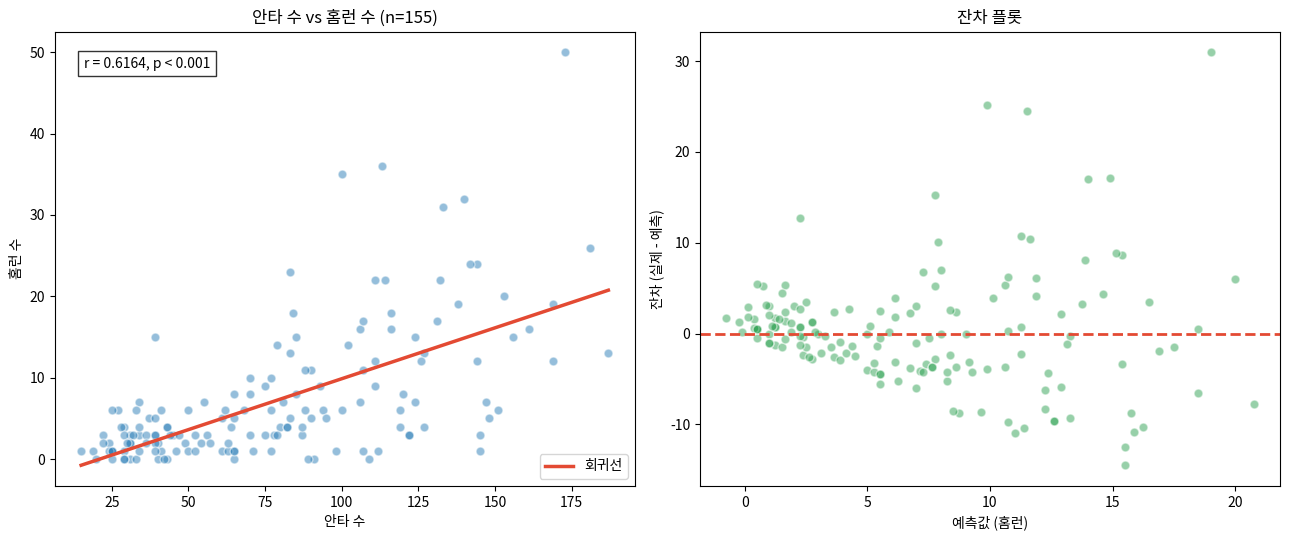

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# 산점도 + 회귀선
ax = axes[0]
ax.scatter(df_final["안타"], df_final["홈런"], alpha=0.5, color="#2c7fb8", edgecolor="white", s=40)
x_line = np.linspace(df_final["안타"].min(), df_final["안타"].max(), 100).reshape(-1, 1)
y_line = lr.predict(pd.DataFrame(x_line, columns=["안타"]))
ax.plot(x_line, y_line, color="#e34a33", linewidth=2.5, label="회귀선")
ax.set_xlabel("안타 수")
ax.set_ylabel("홈런 수")
ax.set_title(f"안타 수 vs 홈런 수 (n={len(df_final)})")
ax.legend()
ax.text(0.05, 0.92, f"r = {r:.4f}, p < 0.001" if p < 0.001 else f"r={r:.4f}, p={p:.4f}",
        transform=ax.transAxes, bbox=dict(facecolor="white", alpha=0.8))

# 잔차 플롯
ax2 = axes[1]
residuals = df_final["홈런"] - lr.predict(df_final[["안타"]])
ax2.scatter(lr.predict(df_final[["안타"]]), residuals, alpha=0.5, color="#31a354", edgecolor="white", s=40)
ax2.axhline(0, color="#e34a33", linestyle="--", linewidth=2)
ax2.set_xlabel("예측값 (홈런)")
ax2.set_ylabel("잔차 (실제 - 예측)")
ax2.set_title("잔차 플롯")

plt.tight_layout()
plt.savefig("hit_hr_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 결론

- 피어슨 상관계수와 p-value 결과를 바탕으로 귀무가설 기각/채택 여부를 확인했습니다.
- R², RMSE 등 성능 지표로 모델의 설명력을 확인했습니다.
- 그래프를 통해 관계의 형태와 잔차 패턴(이분산성 등)을 시각적으로 점검했습니다.

**다음으로 시도해볼 수 있는 것**
- 다중회귀: `장타율`, `타수` 등 변수 추가
- 팀별 그룹 분석
- 이상치(안타는 적지만 홈런이 많은 선수) 별도 분석